[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/ModelsOfTheMotorSystems/blob/master/public_content/in_class/Ex2_Hill_muscle_model.ipynb)


# In-Class Simulation: From Stimulation to Force

In this exercise, you'll explore how stimulation and muscle-tendon length affect muscle force,
using a Hill-type muscle model. Your goal is to match a target force trace by adjusting the input conditions.

You'll use a prebuilt Hill model and investigate how activation dynamics, tendon elasticity,
and contractile properties interact.

## 1. Setup
Run this cell to import the simulation function from Josh Cashaback's model.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

### Create the pre-built muscle model

In [13]:
import numpy as np

def nonlinear_activation(u, A=3.0):
    # Lecture 2 nonlinearity: a(u) = (exp(-A*u)-1)/(exp(-A)-1)
    return (np.exp(-A * u) - 1.0) / (np.exp(-A) - 1.0)

def tendon_force_strain(eps_t, eps_toe=0.024, eps_0=0.04, f_toe=0.33, k_toe=3.0):
    # Lecture 2 tendon model: exponential toe + linear region
    f = np.zeros_like(eps_t, dtype=float)
    toe = eps_t <= eps_toe
    f[toe] = f_toe * (np.exp(k_toe * (eps_t[toe] / eps_toe)) - 1.0) / (np.exp(k_toe) - 1.0)
    lin = ~toe
    slope = (1.0 - f_toe) / (eps_0 - eps_toe)
    f[lin] = f_toe + slope * (eps_t[lin] - eps_toe)
    return f

def simulate_hill_model(time, stim, L_MT):
    """
    Compact Hill-type model aligned with Lecture 2 equations and constants.

    Parameters:
        time (np.ndarray): Time vector (seconds)
        stim (np.ndarray): Neural excitation signal (0 to 1)
        L_MT (np.ndarray): Muscle-tendon unit length (normalized)

    Returns:
        dict with activation state, tendon force, and total force
    """
    dt = time[1] - time[0]
    n = len(time)

    # Lecture 2-style constants
    tau_act = 0.015
    tau_deact = 0.060
    L_CE_opt = 1.0
    L_SE_slack = 0.50
    F_max = 1.0

    gamma = np.zeros(n)
    F_tendon = np.zeros(n)
    L_CE = np.ones(n) * L_CE_opt
    L_SE = np.ones(n) * L_SE_slack

    for i in range(1, n):
        # Activation dynamics
        tau = tau_act if stim[i] > gamma[i - 1] else tau_deact
        gamma[i] = gamma[i - 1] + dt * (stim[i] - gamma[i - 1]) / tau

        # Nonlinear activation mapping
        a = nonlinear_activation(gamma[i], A=3.0)

        # Active force-length at current CE length
        fl = np.exp(-((L_CE[i - 1] - L_CE_opt) / 0.45) ** 2)
        F_iso = a * fl * F_max

        # CE update toward force balance (gentle gain avoids overshoot spikes)
        F_err = F_tendon[i - 1] - F_iso
        L_CE[i] = np.clip(L_CE[i - 1] + dt * 1.2 * F_err, 0.8, 1.2)

        # Tendon geometry and force-strain
        L_SE[i] = max(L_MT[i] - L_CE[i], L_SE_slack)
        eps_t = max((L_SE[i] - L_SE_slack) / L_SE_slack, 0.0)
        F_tendon[i] = tendon_force_strain(np.array([eps_t]))[0]

    # Clip extreme transients for a stable classroom tuning task
    F_tendon = np.clip(F_tendon, 0.0, 1.2)

    return {
        'time': time,
        'activation': gamma,
        'F_tendon': F_tendon,
        'L_CE': L_CE,
        'F_total': F_tendon
    }

## 2. Define a Target Force Profile
This is the target force profile you should try to match using stimulation and length inputs.

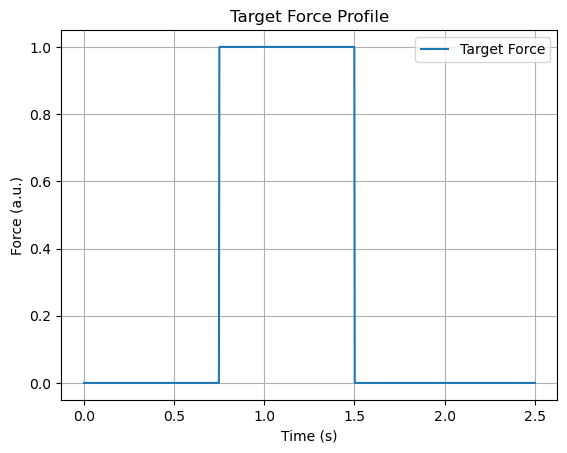

In [9]:
# Target force: plateau profile
time = np.linspace(0, 2.5, 1000)
target_force = np.zeros_like(time)
target_force[(time > 0.75) & (time < 1.50)] = 1.0

plt.plot(time, target_force, label='Target Force')
plt.title('Target Force Profile')
plt.xlabel('Time (s)')
plt.ylabel('Force (a.u.)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Try Your Own Inputs
### Task 1: Tune simulation
Adjust the stimulation and muscle-tendon length to try to match the target force profile.

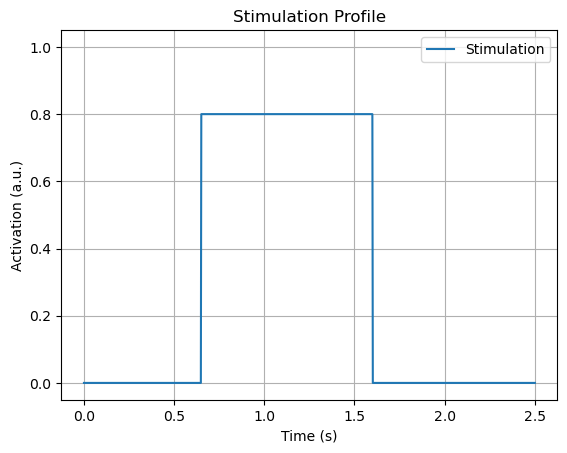

In [10]:
# Student input to tune: stimulation timing and amplitude
stim = np.zeros_like(time)
stim[(time > 0.65) & (time < 1.60)] = 0.80  # Try changing timing and amplitude

plt.plot(time, stim, label='Stimulation')
plt.title('Stimulation Profile')
plt.xlabel('Time (s)')
plt.ylabel('Activation (a.u.)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()

### Task 2: try different muscle-tendon lengths

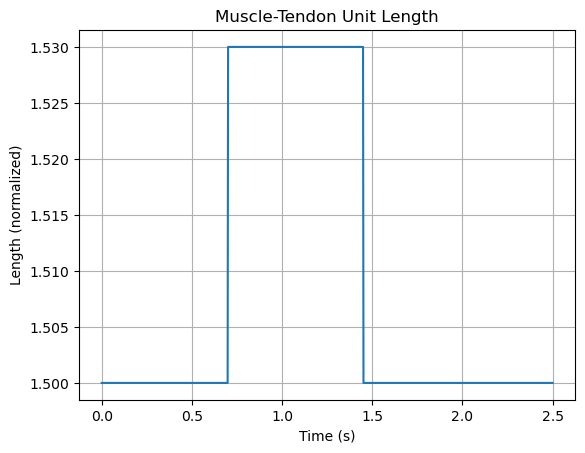

In [11]:
# Student input to tune: MTU length trajectory
L_MT = np.ones_like(time) * 1.50
L_MT[(time > 0.70) & (time < 1.45)] = 1.53  # Try changing baseline and stretch window

plt.plot(time, L_MT)
plt.title('Muscle-Tendon Unit Length')
plt.xlabel('Time (s)')
plt.ylabel('Length (normalized)')
plt.grid(True)
plt.show()

### Task 3: Run the simulation with your chosen inputs

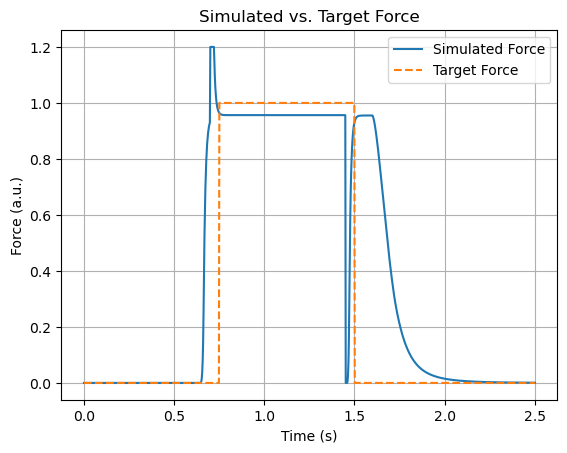

In [14]:
results = simulate_hill_model(time, stim, L_MT)

plt.plot(time, results['F_total'], label='Simulated Force')
plt.plot(time, target_force, '--', label='Target Force')
plt.title('Simulated vs. Target Force')
plt.xlabel('Time (s)')
plt.ylabel('Force (a.u.)')
plt.legend()
plt.grid(True)
plt.show()

### Task 4: Reflect

#### Please edit this markdown to answer the following questions
- What changes to the stimulation pattern affected the shape or timing of the force?
- How did the muscle-tendon length influence the total force?
- Could you get the force to match the target?
